# 文件: chart_169_1.py

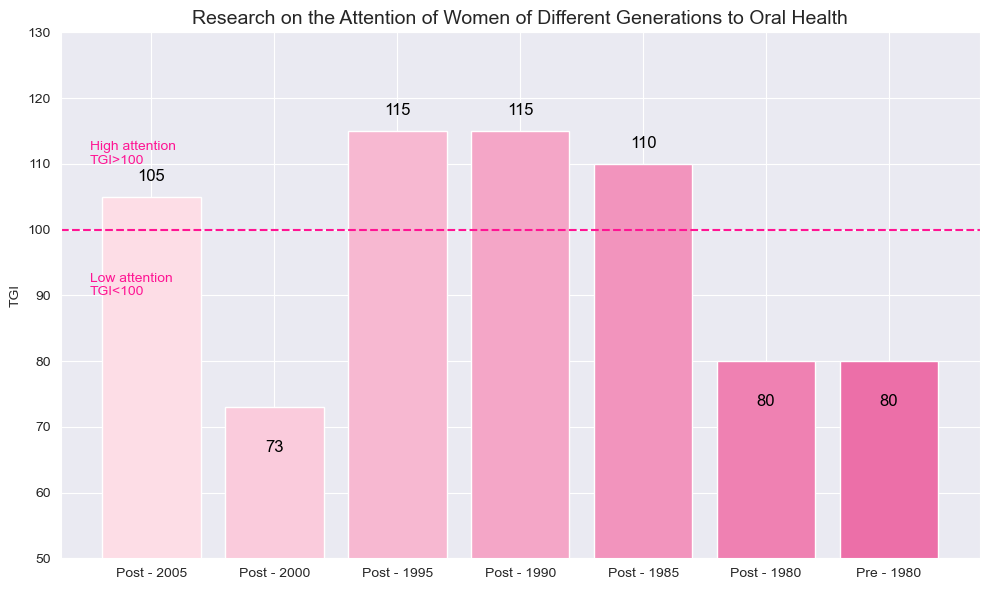

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

# Data
labels = ['Post - 2005', 'Post - 2000', 'Post - 1995', 'Post - 1990', 'Post - 1985', 'Post - 1980', 'Pre - 1980']
values = [105, 73, 115, 115, 110, 80, 80]

# Color setting: Light pink -> Dark pink gradient
cmap = mcolors.LinearSegmentedColormap.from_list("pink_gradient", ["#fddde6", "#ec6fa8"])
colors = [cmap(i / (len(values) - 1)) for i in range(len(values))]

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(labels, values, color=colors)

# Auxiliary lines and annotations
ax.axhline(100, color='deeppink', linestyle='--', linewidth=1.5)
for bar, val in zip(bars, values):
    va = 'bottom' if val >= 100 else 'top'
    ax.text(bar.get_x() + bar.get_width()/2, val + (2 if val >= 100 else -5), f'{val}',
            ha='center', va=va, fontsize=12, color='black')

# Title and description
ax.set_title('Research on the Attention of Women of Different Generations to Oral Health', fontsize=14)
ax.set_ylabel('TGI')
ax.set_ylim(50, 130)
ax.text(-0.5, 110, 'High attention\nTGI>100', color='deeppink', fontsize=10)
ax.text(-0.5, 90, 'Low attention\nTGI<100', color='deeppink', fontsize=10)

plt.tight_layout()
plt.show()

# 文件: chart_169_2.py

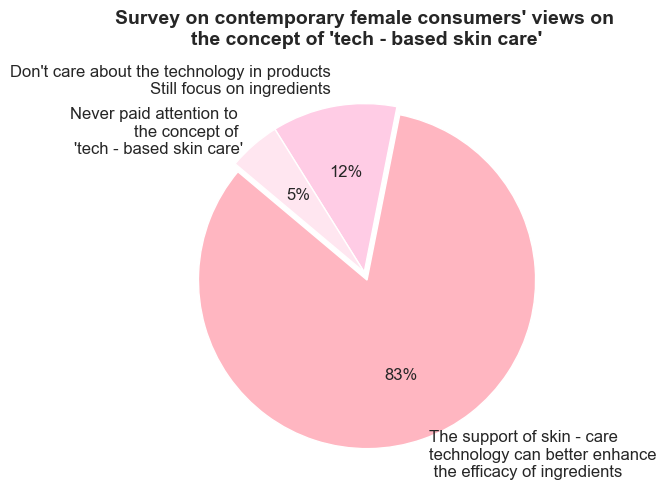

In [7]:
import matplotlib.pyplot as plt

# Data
labels = [
    "The support of skin - care \n"
    "technology can better enhance\n"
    " the efficacy of ingredients",  # 这里“发挥成分功效”英文可改为 "enhance the efficacy of ingredients"
    "Don't care about the technology in products\nStill focus on ingredients\n",
    "Never paid attention to \nthe concept of \n'tech - based skin care'"
]
sizes = [83, 12, 5]
colors = ['#FFB6C1', '#FFCCE5', '#FFE6F0']  # Gradient of pink tones
explode = (0.05, 0, 0)  # Highlight the first slice

# Plotting
fig, ax = plt.subplots(figsize=(7, 5))
wedges, texts, autotexts = ax.pie(
    sizes,
    explode=explode,
    labels=labels,
    colors=colors,
    autopct='%1.0f%%',
    startangle=140,
    textprops={'fontsize': 12},
    wedgeprops={'linewidth': 1, 'edgecolor': 'white'}
)

ax.axis('equal')  # Ensure the pie chart is circular
plt.title("Survey on contemporary female consumers' views on \nthe concept of 'tech - based skin care'", fontsize=14, weight='bold',pad=30)
plt.tight_layout()
plt.show()

# 文件: chart_169_3.py

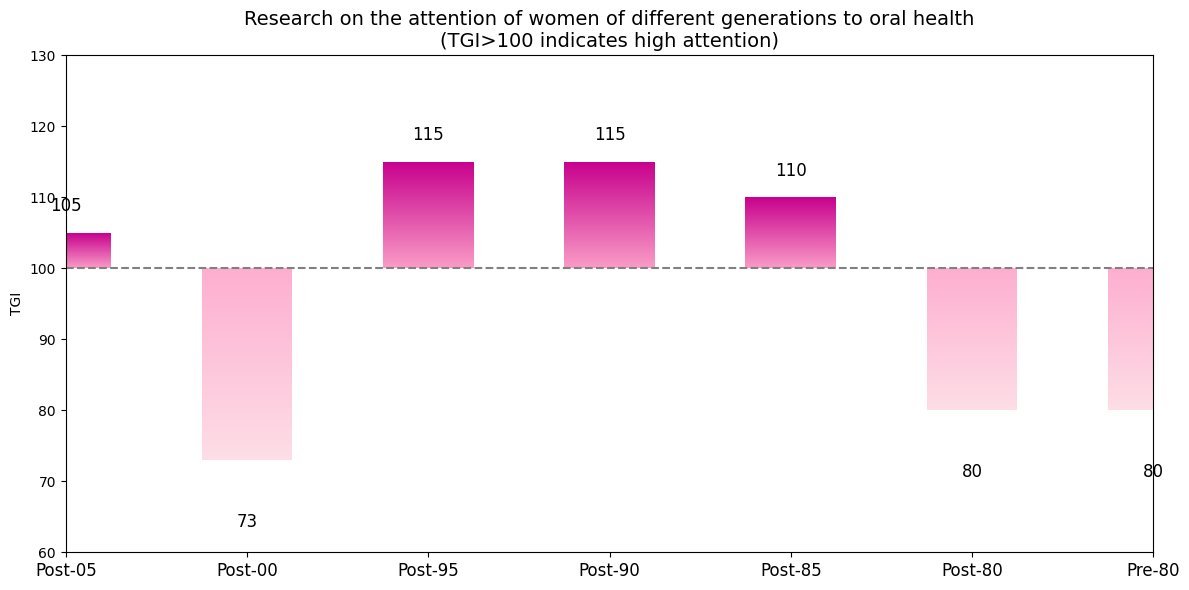

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
from matplotlib.colors import LinearSegmentedColormap

# Data
generations = ['Post-05', 'Post-00', 'Post-95', 'Post-90', 'Post-85', 'Post-80', 'Pre-80']
values = [105, 73, 115, 115, 110, 80, 80]

# Gradient rectangle generation function
def gradient_rect(ax, x, y, width, height, color1, color2, vertical=True):
    cmap = LinearSegmentedColormap.from_list("custom_gradient", [color1, color2])
    n = 100
    for i in range(n):
        if vertical:
            yi = y + i * height / n
            hi = height / n
            rect = Rectangle((x, yi), width, hi, color=cmap(i / n), linewidth=0)
        else:
            xi = x + i * width / n
            wi = width / n
            rect = Rectangle((xi, y), wi, height, color=cmap(i / n), linewidth=0)
        ax.add_patch(rect)

# Create a chart
fig, ax = plt.subplots(figsize=(12, 6))
bar_width = 0.5
x = np.arange(len(generations))

# Draw a gradient bar chart
for i, val in enumerate(values):
    if val >= 100:
        gradient_rect(ax, x[i] - bar_width / 2, 100, bar_width, val - 100, '#f99bc5', '#c7008d', vertical=True)
    else:
        gradient_rect(ax, x[i] - bar_width / 2, val, bar_width, 100 - val, '#fddde6', '#fdaecf', vertical=True)

# Add auxiliary lines and text
ax.axhline(100, color='gray', linestyle='--')
for i, v in enumerate(values):
    va = -10 if v < 100 else 5
    ax.text(x[i], v + va, str(v), color='black', ha='center', va='bottom' if v < 100 else 'top', fontsize=12)

# Set axis labels
ax.set_xticks(x)
ax.set_xticklabels(generations, fontsize=12)
ax.set_ylabel('TGI')
ax.set_ylim(60, 130)
ax.set_title('Research on the attention of women of different generations to oral health\n(TGI>100 indicates high attention)', fontsize=14)

# Display the chart
plt.tight_layout()
plt.show()

# 文件: chart_169_4.py

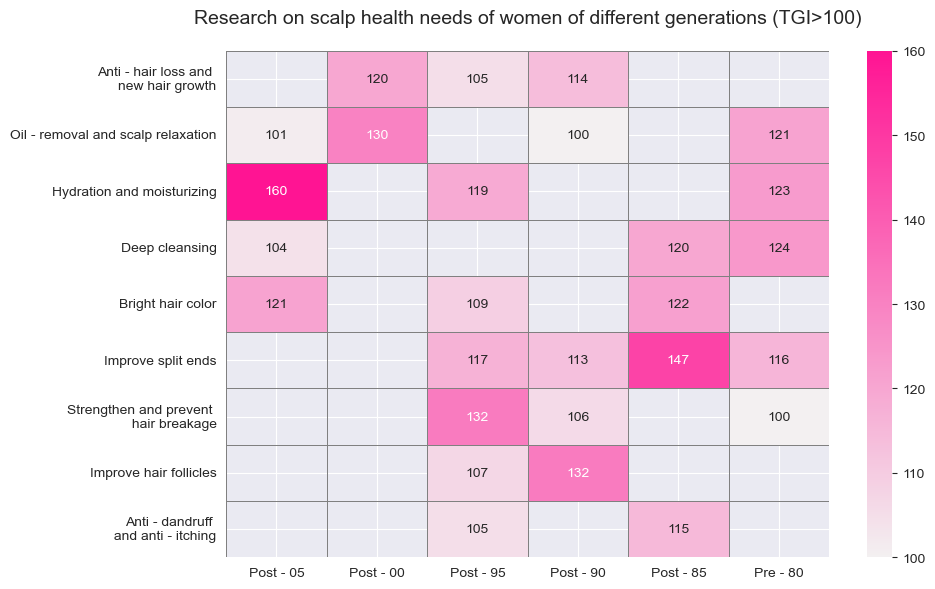

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Data
labels = ["Anti - hair loss and \n"
          "new hair growth",
          "Oil - removal and scalp relaxation",
          "Hydration and moisturizing",
          "Deep cleansing",
          "Bright hair color",
          "Improve split ends",
          "Strengthen and prevent \n hair breakage",
          "Improve hair follicles",
          "Anti - dandruff \n and anti - itching"]
columns = ["Post - 05", "Post - 00", "Post - 95", "Post - 90", "Post - 85", "Pre - 80"]
data = [
    [96, 120, 105, 114, 95, 49],
    [101, 130, 82, 100, 96, 121],
    [160, 88, 119, 90, 58, 123],
    [104, 95, 72, 96, 120, 124],
    [121, 93, 109, 67, 122, 87],
    [78, 43, 117, 113, 147, 116],
    [45, 74, 132, 106, 85, 100],
    [95, 78, 107, 132, 60, 85],
    [85, 93, 105, 96, 115, 98]
]

# Create a DataFrame
df = pd.DataFrame(data, index=labels, columns=columns)

# Set values below 100 to NaN
masked_df = df.copy()
masked_df[df < 100] = np.nan

# Select color palette
cmap = sns.light_palette("deeppink", as_cmap=True)

# Draw a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(masked_df, annot=df, fmt="d", cmap=cmap, linewidths=0.5, linecolor='grey', cbar=True,
            mask=df < 100, annot_kws={"size": 10}, square=False)

# Set title and style
plt.title("Research on scalp health needs of women of different generations (TGI>100)", fontsize=14, pad=20)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()